# 03 Retention & Cohort

Measure D1/D7/D14/D30 retention and cohort retention.

In [1]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
from src.data_processing import load_events, compute_retention, build_cohort_table
from src.visualization import plot_retention_curve, plot_cohort_heatmap

EVENTS_PATH = "C:/Users/chuan/OneDrive/Desktop/Intern_Prepare/业务准备/ecommerce-user-retention-analysis/data/events.csv"
OUTPUT_DIR = "C:/Users/chuan/OneDrive/Desktop/Intern_Prepare/业务准备/ecommerce-user-retention-analysis/outputs/figures"

df = load_events(EVENTS_PATH)
retention_user = compute_retention(df, horizons=(1, 7, 14, 30))
retention_curve = retention_user.groupby("horizon")["retained"].mean().reset_index()
cohort = build_cohort_table(df)

retention_curve

,horizon,retained
0,1,0.027243
1,7,0.005292
2,14,0.002858
3,30,0.001234


In [3]:
plot_retention_curve(retention_user, OUTPUT_DIR)
plot_cohort_heatmap(cohort, OUTPUT_DIR)

'C:\\Users\\chuan\\OneDrive\\Desktop\\Intern_Prepare\\业务准备\\ecommerce-user-retention-analysis\\outputs\\figures\\cohort_retention.png'

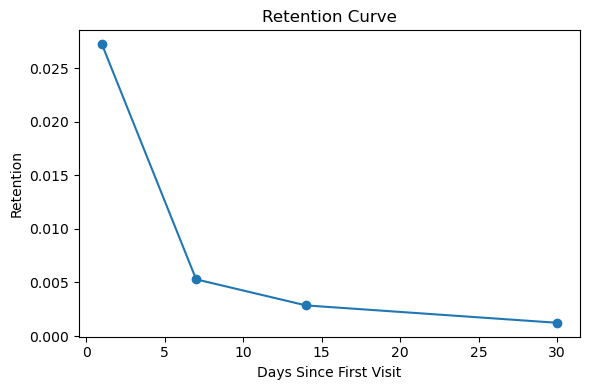

In [4]:
plt.figure(figsize=(6, 4))
plt.plot(retention_curve["horizon"], retention_curve["retained"], marker="o")
plt.title("Retention Curve")
plt.xlabel("Days Since First Visit")
plt.ylabel("Retention")
plt.tight_layout()
plt.show()

In [5]:
cohort.style.format("{:.2%}")

cohort_index,0,1,2,3,4
cohort_month,,,,,
2015-05,100.00%,4.76%,2.86%,1.89%,1.05%
2015-06,100.00%,4.23%,2.02%,0.96%,0.00%
2015-07,100.00%,3.08%,1.09%,0.00%,0.00%
2015-08,100.00%,2.43%,0.00%,0.00%,0.00%
2015-09,100.00%,0.00%,0.00%,0.00%,0.00%
